In [1]:
#source activate newEnv
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
library(tibble)
library(broom)
library("parallel")
library(tidyr)
library(stringr)
library(qvalue)

Warning message:
“package ‘qvalue’ was built under R version 4.4.2”


# Prep for States

In [24]:
#E1 - Uknown
#E2 - Repressive
#E3 - Open
#E4 - Weak
#E5 - Active
states <- c(Uknown='E1',Repressive='E2',Open='E3',Weak='E4',Active='E5')

states[1]

for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    all.annot <- read.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_',cell,'_annotate.bed'))
    for (i in 1:length(states)) {
        print(names(states)[i])
        print(states[i])
        filter(all.annot, V4 == states[i]) %>%
            write.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/cre.states/', cell, '_', names(states)[i], '.bed'),
                       quote=F, col.names=F, row.names=F, sep='\t')
    }
}

Uknown 
  "E1"

[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
Active 
  "E5" 
[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
Active 
  "E5" 
[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
Active 
  "E5" 
[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
Active 
  "E5" 
[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
Active 
  "E5" 
[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
Active 
  "E5" 
[1] "Uknown"
Uknown 
  "E1" 
[1] "Repressive"
Repressive 
      "E2" 
[1] "Open"
Open 
"E3" 
[1] "Weak"
Weak 
"E4" 
[1] "Active"
A

# Write State commands

In [2]:
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/DAR_clusters_High_Fibrosis/', full.names = TRUE)
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/DAR_clusters_High_Fibrosis'

In [3]:
#dir.create('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [4]:
setwd('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [5]:
head(trait_beds)

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed"
[2] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.EUR.MVP.2021.credset.bed"  
[3] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_WIDE_Hg38.bed"       
[4] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_Hg38.bed"            
[5] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_Hg38.bed"            
[6] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_EARLY_Hg38.bed"

In [6]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/'

In [32]:
Sys.time()
commands <- character()
homer.commands <- character()

# Run for DE sites
for(FILE in trait_beds[1]){
    cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed',
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)

    bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
    
    for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    
        for (state in names(states)) { 
            background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_',CELL,'_annotate.bed')

            input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/', CELL, '_', state, '.bed')
            commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                               out.dir,CELL,'__',state,'__cre.states.results'))
            homer.commands <- c(homer.commands, paste0('findMotifsGenome.pl ',input_name,' hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.',
                         state,'.',CELL,'/ -size 200 -bg ',background_name,' -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
        }
    }
}

Sys.time()

length(commands)
head(commands)
tail(commands)

commands[str_detect(commands, 'nfs')]

length(homer.commands)
head(homer.commands)
tail(homer.commands)

homer.commands[str_detect(homer.commands, 'nfs')]

[1] "2025-04-08 22:12:51 PDT"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed



[1] "2025-04-08 22:12:51 PDT"

[1] 50

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Uknown.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Uknown__cre.states.results"                                    
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Repressive.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Repressive__cre.states.results"                            
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Open.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Open__cre.states.results"                                        
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Weak.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Weak__cre.states.results"                                        
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Active.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Active__cre.states.results"                                    
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/Cholangiocyte_Uknown.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_Cholangiocyte_annotate.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte__Uknown__cre.states.results"

...

character(0)

[1] 50

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Uknown.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Uknown.B/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                    
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Repressive.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Repressive.B/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                            
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Open.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Open.B/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                        
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Weak.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Weak.B/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                        
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/B_Active.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Active.B/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_B_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                    
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/Cholangiocyte_Uknown.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Uknown.Cholangiocyte/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_Cholangiocyte_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/Schwann_Active.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Active.Schwann/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_Schwann_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/T_Uknown.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Uknown.T/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_T_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                  
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/T_Repressive.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Repressive.T/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_T_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"          
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/T_Open.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Open.T/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_T_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                      
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/T_Weak.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Weak.T/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_T_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                      
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.states/T_Active.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.states.Active.T/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_T_annotate.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

character(0)

In [33]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/250408_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

In [31]:
write.table(homer.commands, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250408_commands.txt',col.names=F, row.names=F, quote=F, sep='\t')

# Read FINRICH

In [82]:
out.df <- data.frame()

for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    for (state in names(states)) { 
        file.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/',CELL,'__',state,'__cre.states.results')
        if (!file.exists(file.path)) {
            next
        }
        
        res <- unlist(strsplit(readLines(file.path)[1], ":|,|}"))
        if (!is.na(res[1])){
            results <- data.frame(matrix(ncol=0, nrow=1))
            results$modality <- 'States'
            results$cell_type <- CELL
            results$state <- state
            results$pval <- res[2]
            results$fold_enrich <- res[4]
            results$logOR <- res[6]
            results$conf_lower <- res[8]
            results$conf_upper  <- res[10]
        } else {
            message(file.path)
        }
        out.df <- rbind(out.df, results)
    }
}

dim(out.df)
head(out.df)

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/B__Repressive__cre.states.results

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/Mast__Uknown__cre.states.results

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/Schwann__Uknown__cre.states.results



[1] 49  8

,modality,cell_type,state,pval,fold_enrich,logOR,conf_lower,conf_upper
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,States,T,Active,0.275,1.3038691346901676,0.2938258574190333,-0.8363142537694057,2.2526419325808615
2,States,B,Open,0.0,3.572463712156638,1.6922770697663871,0.6696268621883792,3.225741889805822
3,States,B,Weak,0.55,0.8623402303927366,-0.17026417989142928,-1.1618268017508953,1.2245695312442473
4,States,B,Active,0.281,1.311511873349074,0.3000776629803169,-0.8573310203181927,2.34583567576586
5,States,Cholangiocyte,Uknown,1.0,0.3292229469908027,-1.6104653391728383,-2.5433151207821103,-0.8547989175319495
6,States,Cholangiocyte,Repressive,0.692,0.6684262340472442,-0.43971948175967823,-1.489064308653751,1.2167733887551795


In [91]:
out.df.fdr <- arrange(out.df, pval) %>%
    mutate(qval = qvalue(as.numeric(pval))$qvalue)
out.df.fdr

modality,cell_type,state,pval,fold_enrich,logOR,conf_lower,conf_upper,qval
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
States,B,Open,0.0,3.572463712156638,1.6922770697663871,0.6696268621883792,3.225741889805822,0.00000000
States,Hepatocytes,Active,0.0,2.826848977975229,2.6935038464699366,1.8261126153421365,3.588970969547363,0.00000000
States,Cholangiocyte,Open,0.001,3.266080395859679,1.53737795075012,0.4840509841249281,3.144771350771253,0.01633333
States,Schwann,Weak,0.004,3.358546178190914,1.4627383568823034,0.3350727843673167,3.4058200427710394,0.04900000
States,Endothelial,Active,0.005,2.09716530822627,1.0812804200358979,0.19617985013369954,2.142844779076966,0.04900000
States,Myeloid,Active,0.019,1.8797536903329282,0.919119925612297,0.019313534352717765,1.978527768725915,0.15516667
States,HSC,Active,0.039,1.8947499227359725,0.8420419251464833,-0.14044952775020936,2.136118809453828,0.23887500
States,HSC,Active,0.039,1.8947499227359725,0.8420419251464833,-0.14044952775020936,2.136118809453828,0.23887500
States,Schwann,Active,0.044,4.029530840676352,1.3978142511492995,-1.0526985538580074,96.60829362808751,0.23955556


In [92]:
write.table(out.df.fdr, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/250408_cre.states.tsv',
           col.names=T, row.names=F, quote=F, sep='\t')

In [ ]:
ggplot()

# Read HOMER

In [127]:
homer.state <- data.frame()
for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    for (state in names(states)) { 
        file <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/outs/cre.states.',state,'.',CELL,'/knownResults.txt')
        if (!file.exists(file)) {
            next
        }
        homer.state <- vroom::vroom(file) %>%
            mutate(celltype=CELL,state=state) %>%
            select(Motif.Name=`Motif Name`, p.value=`P-value`, log.p.value=`Log P-value`, 
                   q.value=`q-value (Benjamini)`, num.target.seqs.with.motif=contains("# of Target Sequences with Motif(of "),
                  perc.target.seqs.with.motif=`% of Target Sequences with Motif`,
                  num.background.seqs.with.motif=contains("# of Background Sequences with Motif(of "),
                  perc.background.seqs.with.motif=`% of Background Sequences with Motif`, celltype, state) %>%
            mutate(perc.target.seqs.with.motif=as.numeric(str_remove(perc.target.seqs.with.motif, '%')),
                  perc.background.seqs.with.motif=as.numeric(str_remove(perc.background.seqs.with.motif, '%'))) %>%
            mutate(FC=(perc.target.seqs.with.motif/perc.background.seqs.with.motif),
                  L2FC=log2(abs(FC))) %>%
            rbind(homer.state)
    }
}

print(692 * 10 * 5)
dim(homer.state)
head(homer.state)

write.table(homer.state, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250408_cRE_states_JASPAR2022.tsv', sep='\t', col.names=T, row.names=F, quote=F)

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-

[1] 34600


[1] 33908    12

Motif.Name,p.value,log.p.value,q.value,num.target.seqs.with.motif,perc.target.seqs.with.motif,num.background.seqs.with.motif,perc.background.seqs.with.motif,celltype,state,FC,L2FC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
MA0098.3_ETS1,1e-307,-3139,0,7936,15.08,23229.5,5.60,T,Active,2.692857,1.429138
MA0076.2_ELK4,1e-307,-3070,0,10840,20.60,38566.9,9.29,T,Active,2.217438,1.148894
MA0764.3_ETV4,1e-307,-2405,0,5980,11.36,17107.5,4.12,T,Active,2.757282,1.463247
MA0760.1_ERF,1e-307,-2281,0,5647,10.73,16078.0,3.87,T,Active,2.772610,1.471245
MA0475.2_FLI1,1e-307,-2239,0,5213,9.90,14247.8,3.43,T,Active,2.886297,1.529220
MA1484.1_ETS2,1e-307,-2143,0,5790,11.00,17373.3,4.19,T,Active,2.625298,1.392481


x
/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250408_cRE_states_JASPAR2022.tsv


In [120]:
filter(homer.state, celltype=='Hepatocytes' & q.value < 0.05)

Motif.Name,p.value,log.p.value,q.value,num.target.seqs.with.motif,perc.target.seqs.with.motif,num.background.seqs.with.motif,perc.background.seqs.with.motif,celltype,state,FC,L2FC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
MA0484.2_HNF4G,1e-307,-2264.0,0,19037,10.06,24182.9,6.05,Hepatocytes,Active,1.662810,0.7336233
MA0114.4_HNF4A,1e-307,-2255.0,0,18919,10.00,24016.6,6.01,Hepatocytes,Active,1.663894,0.7345631
MA1148.1_PPARA::RXRA,1e-307,-1666.0,0,16380,8.66,21637.8,5.41,Hepatocytes,Active,1.600739,0.6787384
MA1494.1_HNF4A,1e-307,-1662.0,0,3954,2.09,2859.6,0.72,Hepatocytes,Active,2.902778,1.5374341
MA0153.2_HNF1B,1e-307,-1656.0,0,6697,3.54,6454.8,1.61,Hepatocytes,Active,2.198758,1.1366887
MA1574.1_THRB,1e-307,-1604.0,0,12049,6.37,14696.9,3.68,Hepatocytes,Active,1.730978,0.7915876
MA1550.1_PPARD,1e-307,-1506.0,0,5377,2.84,4881.7,1.22,Hepatocytes,Active,2.327869,1.2190098
MA1537.1_NR2F1,1e-307,-1355.0,0,5736,3.03,5633.8,1.41,Hepatocytes,Active,2.148936,1.1036226
MA0046.2_HNF1A,1e-307,-1267.0,0,8343,4.41,9720.8,2.43,Hepatocytes,Active,1.814815,0.8598223


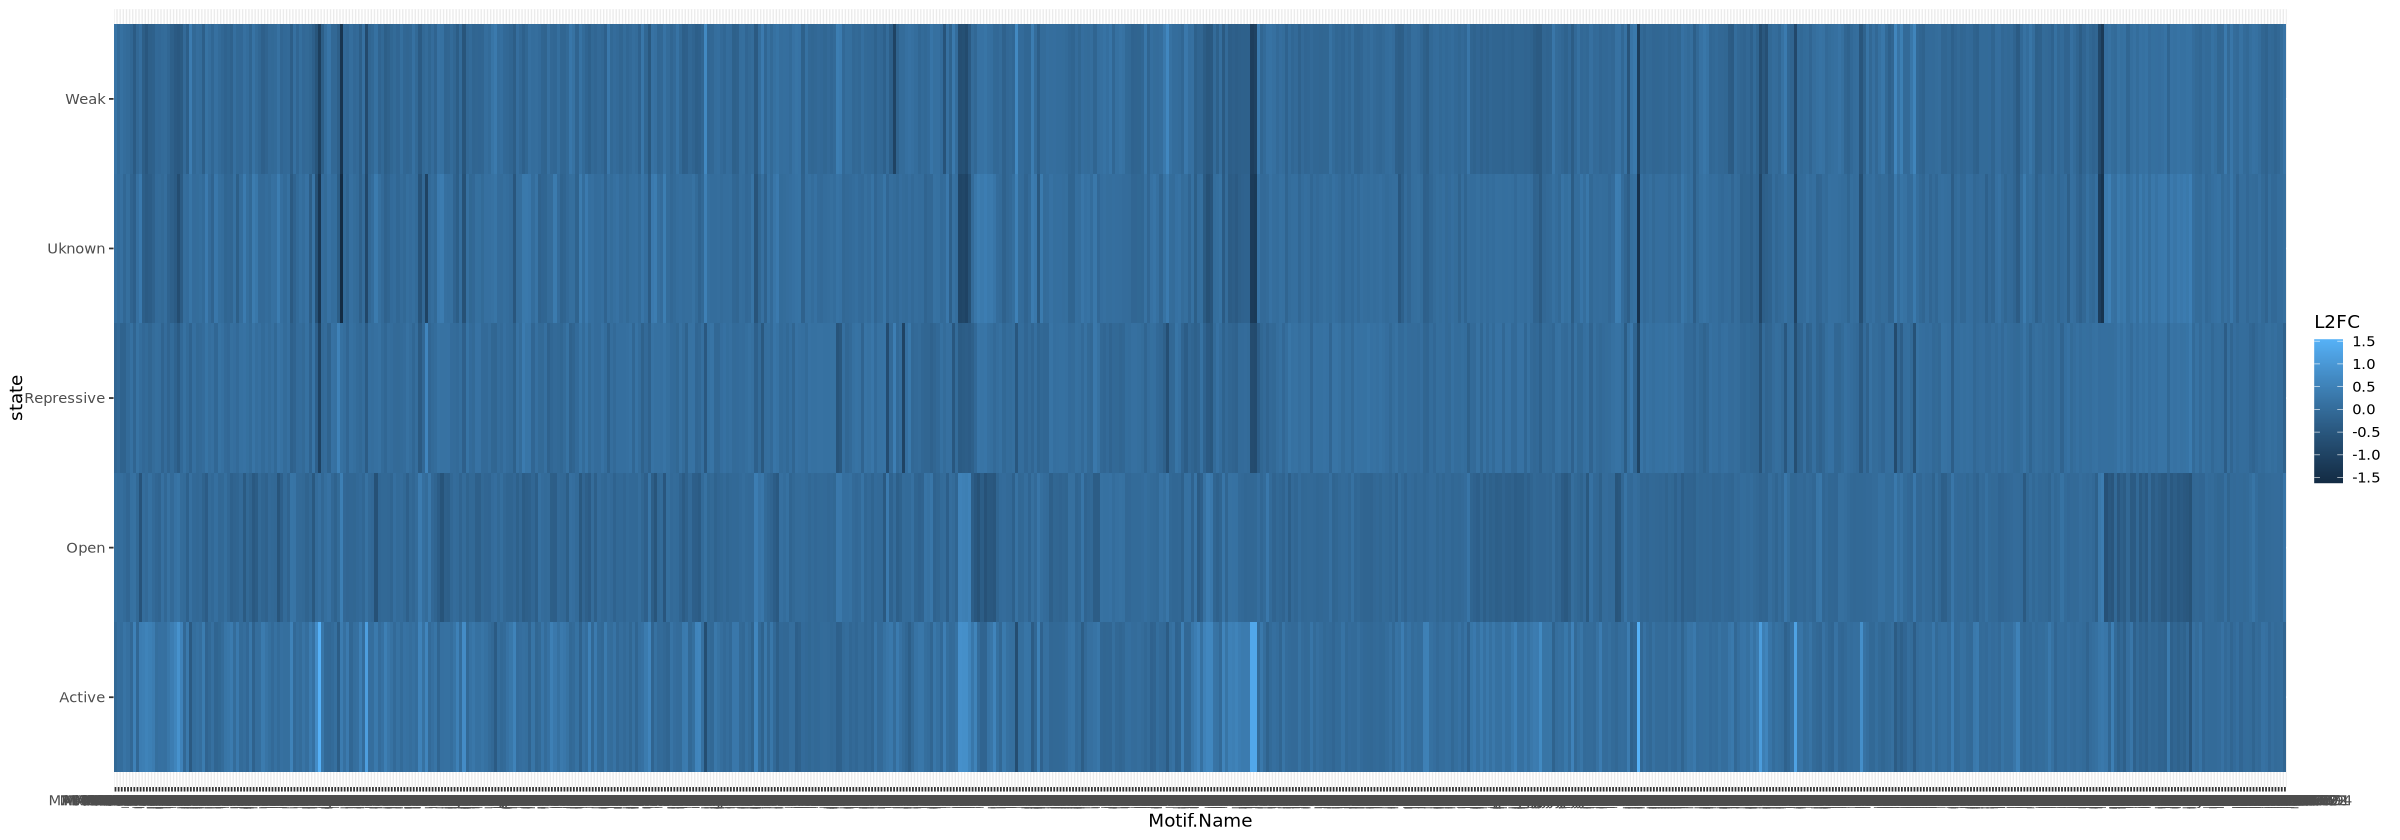

In [122]:
options(repr.plot.width=20)
filter(homer.state, celltype=='Hepatocytes') %>%
    ggplot(aes(x=Motif.Name, y=state, fill=L2FC)) + geom_tile()

In [125]:
hep.heat.state.motifs <- homer.state %>%
    filter(celltype=='Hepatocytes') %>%
    select(Motif.Name, state, L2FC) %>%
    pivot_wider(names_from = 'state', values_from = L2FC) %>%
    tibble::column_to_rownames(var='Motif.Name') 

max_indices <- max.col(hep.heat.state.motifs)
permutation_vector <- order(max_indices)
sorted.hep.heat.state.motifs <- hep.heat.state.motifs[permutation_vector, ]

pheatmap(sorted.hep.heat.state.motifs, )

,Active,Weak,Open,Repressive,Uknown
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0484.2_HNF4G,0.7336233,-0.5552851,-0.002042032,-0.271364286,-0.6454505
MA0114.4_HNF4A,0.7345631,-0.5477514,0.000000000,-0.273625051,-0.6452585
MA1148.1_PPARA::RXRA,0.6787384,-0.4240423,-0.129847562,-0.245640143,-0.4244057
MA1494.1_HNF4A,1.5374341,-1.1497471,0.000000000,-0.977973694,-1.4452377
MA0153.2_HNF1B,1.1366887,-0.8125764,0.139724764,-0.376563351,-0.8917837
MA1574.1_THRB,0.7915876,-0.5231674,-0.067263227,-0.434321083,-0.6978393
MA1550.1_PPARD,1.2190098,-0.8552649,-0.114770187,-0.702319451,-1.0000000
MA1537.1_NR2F1,1.1036226,-0.7441611,-0.184424571,-0.571352069,-0.9233787
MA0046.2_HNF1A,0.8598223,-0.4718687,0.206072168,-0.392914688,-0.7345986


In [ ]:
max_indices <- max.col(mat)
permutation_vector <- order(max_indices)
smat <- mat[permutation_vector, ]

# Prep for DAC - High/Low Fib

In [95]:
read.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/02_DESEQ_ATAC/gaulton.peaks/Hepatocytes_High_Fibrosis_vs_Control.dds.res')) %>% 
    head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr8-138582657-138582957,25.41070,3.272786,0.3224840,10.148679,3.358780e-24,8.791863e-19
chr9-107180246-107180540,17.25307,2.541070,0.2516038,10.099490,5.553048e-24,8.791863e-19
chr4-180923510-180923810,10.89005,3.323915,0.3331751,9.976480,1.931993e-23,2.039218e-18
chr6-47195384-47195684,11.49622,2.579676,0.2651789,9.728061,2.289144e-22,1.812143e-17
chr1-228964216-228964516,15.26678,2.848511,0.3001337,9.490809,2.292477e-21,1.451826e-16
chr8-138569842-138570142,20.48744,3.416313,0.3643530,9.376384,6.827439e-21,3.603181e-16


In [100]:
contrasts <- c('High_Fibrosis_vs_Control','Low_Fibrosis_vs_Control')

for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    for (contrast in contrasts) {
        deseq.file <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/02_DESEQ_ATAC/gaulton.peaks/',cell,'_',contrast,'.dds.res')
        if (!file.exists(deseq.file)) {
            next
        }
        
        deseq <- read.table(deseq.file)
        deseq %>% rownames() %>% str_split('-', simplify=T) %>%
            write.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/',cell,'_',contrast,'_background.bed'),
                       sep='\t', col.names=F, row.names=F, quote=F)
        deseq %>% filter(padj < 0.05 & log2FoldChange > 0) %>%
            rownames() %>% str_split('-', simplify=T) %>%
            write.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/',cell,'_',contrast,'_up.bed'),
                       sep='\t', col.names=F, row.names=F, quote=F)
        deseq %>% filter(padj < 0.05 & log2FoldChange < 0) %>%
            rownames() %>% str_split('-', simplify=T) %>%
            write.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/',cell,'_',contrast,'_down.bed'),
                       sep='\t', col.names=F, row.names=F, quote=F)
    }
}

# Write State commands

In [101]:
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/'

In [102]:
#dir.create('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [103]:
setwd('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [104]:
head(trait_beds)

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed"
[2] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.EUR.MVP.2021.credset.bed"  
[3] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_WIDE_Hg38.bed"       
[4] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_Hg38.bed"            
[5] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_Hg38.bed"            
[6] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_EARLY_Hg38.bed"

In [105]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/'

In [129]:
Sys.time()
commands <- character()
homer.commands <- character()

# Run for DE sites
for(FILE in trait_beds[1]){
    cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed',
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)

    bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
    
    for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    
        for (contrast in contrasts) {
            for (direction in c('up','down')) {
                background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/',CELL,'_',contrast,'_background.bed')

                input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/',CELL,'_',contrast,'_',direction,'.bed')
                commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                                   out.dir,CELL,'__',contrast,'__',direction,'__High_Low_DAC.results'))
                homer.commands <- c(homer.commands, paste0('findMotifsGenome.pl ',input_name,' hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.',
                             contrast,'.',CELL,'.',direction,'/ -size 200 -bg ',background_name,' -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
            }
        }
    }
}

Sys.time()

length(commands)
head(commands)
tail(commands)

commands[str_detect(commands, 'nfs')]

length(homer.commands)
head(homer.commands)
tail(homer.commands)

homer.commands[str_detect(homer.commands, 'nfs')]

[1] "2025-04-09 16:42:24 PDT"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed



[1] "2025-04-09 16:42:24 PDT"

[1] 40

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_High_Fibrosis_vs_Control_up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_High_Fibrosis_vs_Control_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__High_Fibrosis_vs_Control__up__High_Low_DAC.results"                                        
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_High_Fibrosis_vs_Control_down.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_High_Fibrosis_vs_Control_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__High_Fibrosis_vs_Control__down__High_Low_DAC.results"                                    
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_Low_Fibrosis_vs_Control_up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_Low_Fibrosis_vs_Control_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Low_Fibrosis_vs_Control__up__High_Low_DAC.results"                                           
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_Low_Fibrosis_vs_Control_down.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_Low_Fibrosis_vs_Control_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__Low_Fibrosis_vs_Control__down__High_Low_DAC.results"                                       
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/Cholangiocyte_High_Fibrosis_vs_Control_up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Cholangiocyte_High_Fibrosis_vs_Control_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte__High_Fibrosis_vs_Control__up__High_Low_DAC.results"    
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/Cholangiocyte_High_Fibrosis_vs_Control_down.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Cholangiocyte_High_Fibrosis_vs_Control_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte__High_Fibrosis_vs_Control__down__High_Low_DAC.results"

...

character(0)

[1] 40

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_High_Fibrosis_vs_Control_up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.High_Fibrosis_vs_Control.B.up/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_High_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                        
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_High_Fibrosis_vs_Control_down.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.High_Fibrosis_vs_Control.B.down/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_High_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                    
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_Low_Fibrosis_vs_Control_up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.Low_Fibrosis_vs_Control.B.up/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_Low_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                           
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/B_Low_Fibrosis_vs_Control_down.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.Low_Fibrosis_vs_Control.B.down/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/B_Low_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                       
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/Cholangiocyte_High_Fibrosis_vs_Control_up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.High_Fibrosis_vs_Control.Cholangiocyte.up/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Cholangiocyte_High_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"    
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/Cholangiocyte_High_Fibrosis_vs_Control_down.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.High_Fibrosis_vs_Control.Cholangiocyte.down/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Cholangiocyte_High_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/Schwann_Low_Fibrosis_vs_Control_up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.Low_Fibrosis_vs_Control.Schwann.up/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Schwann_Low_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"    
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/Schwann_Low_Fibrosis_vs_Control_down.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.Low_Fibrosis_vs_Control.Schwann.down/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Schwann_Low_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/T_High_Fibrosis_vs_Control_up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.High_Fibrosis_vs_Control.T.up/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/T_High_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                   
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/T_High_Fibrosis_vs_Control_down.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.High_Fibrosis_vs_Control.T.down/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/T_High_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"               
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/T_Low_Fibrosis_vs_Control_up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.Low_Fibrosis_vs_Control.T.up/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/T_Low_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                      
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/T_Low_Fibrosis_vs_Control_down.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.Low_Fibrosis_vs_Control.T.down/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/T_Low_Fibrosis_vs_Control_background.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

character(0)

In [107]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/250409_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

In [130]:
write.table(homer.commands, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250409_commands.txt',col.names=F, row.names=F, quote=F, sep='\t')

# Read FINRICH

In [82]:
out.df <- data.frame()

for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    for (state in names(states)) { 
        file.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/',CELL,'__',state,'__cre.states.results')
        if (!file.exists(file.path)) {
            next
        }
        
        res <- unlist(strsplit(readLines(file.path)[1], ":|,|}"))
        if (!is.na(res[1])){
            results <- data.frame(matrix(ncol=0, nrow=1))
            results$modality <- 'States'
            results$cell_type <- CELL
            results$state <- state
            results$pval <- res[2]
            results$fold_enrich <- res[4]
            results$logOR <- res[6]
            results$conf_lower <- res[8]
            results$conf_upper  <- res[10]
        } else {
            message(file.path)
        }
        out.df <- rbind(out.df, results)
    }
}

dim(out.df)
head(out.df)

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/B__Repressive__cre.states.results

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/Mast__Uknown__cre.states.results

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/Schwann__Uknown__cre.states.results



[1] 49  8

,modality,cell_type,state,pval,fold_enrich,logOR,conf_lower,conf_upper
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,States,T,Active,0.275,1.3038691346901676,0.2938258574190333,-0.8363142537694057,2.2526419325808615
2,States,B,Open,0.0,3.572463712156638,1.6922770697663871,0.6696268621883792,3.225741889805822
3,States,B,Weak,0.55,0.8623402303927366,-0.17026417989142928,-1.1618268017508953,1.2245695312442473
4,States,B,Active,0.281,1.311511873349074,0.3000776629803169,-0.8573310203181927,2.34583567576586
5,States,Cholangiocyte,Uknown,1.0,0.3292229469908027,-1.6104653391728383,-2.5433151207821103,-0.8547989175319495
6,States,Cholangiocyte,Repressive,0.692,0.6684262340472442,-0.43971948175967823,-1.489064308653751,1.2167733887551795


In [91]:
out.df.fdr <- arrange(out.df, pval) %>%
    mutate(qval = qvalue(as.numeric(pval))$qvalue)
out.df.fdr

modality,cell_type,state,pval,fold_enrich,logOR,conf_lower,conf_upper,qval
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
States,B,Open,0.0,3.572463712156638,1.6922770697663871,0.6696268621883792,3.225741889805822,0.00000000
States,Hepatocytes,Active,0.0,2.826848977975229,2.6935038464699366,1.8261126153421365,3.588970969547363,0.00000000
States,Cholangiocyte,Open,0.001,3.266080395859679,1.53737795075012,0.4840509841249281,3.144771350771253,0.01633333
States,Schwann,Weak,0.004,3.358546178190914,1.4627383568823034,0.3350727843673167,3.4058200427710394,0.04900000
States,Endothelial,Active,0.005,2.09716530822627,1.0812804200358979,0.19617985013369954,2.142844779076966,0.04900000
States,Myeloid,Active,0.019,1.8797536903329282,0.919119925612297,0.019313534352717765,1.978527768725915,0.15516667
States,HSC,Active,0.039,1.8947499227359725,0.8420419251464833,-0.14044952775020936,2.136118809453828,0.23887500
States,HSC,Active,0.039,1.8947499227359725,0.8420419251464833,-0.14044952775020936,2.136118809453828,0.23887500
States,Schwann,Active,0.044,4.029530840676352,1.3978142511492995,-1.0526985538580074,96.60829362808751,0.23955556


In [92]:
write.table(out.df.fdr, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/250408_cre.states.tsv',
           col.names=T, row.names=F, quote=F, sep='\t')

In [ ]:
ggplot()

# Read HOMER

In [135]:
other.res.colnames <- c('Motif.Name','p.value','Perc_Target_Motif','Perc_Background_Motif','cell','modality','direction','sig','contrast','FC','L2FC','X.Log10p','padj','qval','q.value')
other.res.colnames

[1] "Motif.Name"            "p.value"               "Perc_Target_Motif"    
 [4] "Perc_Background_Motif" "cell"                  "modality"             
 [7] "direction"             "sig"                   "contrast"             
[10] "FC"                    "L2FC"                  "X.Log10p"             
[13] "padj"                  "qval"                  "q.value"

In [146]:
homer.dac <- data.frame()
for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    for (contrast in c('High_Fibrosis_vs_Control','Low_Fibrosis_vs_Control')) { 
        for (direction in c('up','down')) {
            file <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/outs/High_Low_DAC.',contrast,'.',CELL,'.',direction,'/knownResults.txt')
            if (!file.exists(file)) {
                next
            }
            homer.dac <- vroom::vroom(file) %>%
                mutate(cell=CELL,modality='ATAC',direction=direction, sig='padj',contrast=contrast) %>%
                select(Motif.Name=`Motif Name`, p.value=`P-value`, X.Log10p=`Log P-value`, 
                       q.value=`q-value (Benjamini)`, 
                      Perc_Target_Motif=`% of Target Sequences with Motif`,
                      Perc_Background_Motif=`% of Background Sequences with Motif`, 
                      padj=`q-value (Benjamini)`, qval=`q-value (Benjamini)`, cell, modality, direction, sig, contrast) %>%
                mutate(Perc_Target_Motif=as.numeric(str_remove(Perc_Target_Motif, '%')),
                      Perc_Background_Motif=as.numeric(str_remove(Perc_Background_Motif, '%'))) %>%
                mutate(FC=(Perc_Target_Motif/Perc_Background_Motif),
                      L2FC=log2(abs(FC))) %>%
                rbind(homer.dac)
        }
    }
}

homer.dac <- homer.dac[other.res.colnames]

dim(homer.dac)
head(homer.dac)

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-

[1] 17300    15

Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,X.Log10p,padj,qval,q.value
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA1491.2_GLI3,0.001,16.67,0.60,T,ATAC,down,padj,Low_Fibrosis_vs_Control,27.783333,4.796148,-8.727,0.1122,0.1122,0.1122
MA0100.3_MYB,0.010,27.78,6.93,T,ATAC,down,padj,Low_Fibrosis_vs_Control,4.008658,2.003119,-5.055,1.0000,1.0000,1.0000
MA0138.2_REST,0.100,16.67,2.81,T,ATAC,down,padj,Low_Fibrosis_vs_Control,5.932384,2.568612,-4.330,1.0000,1.0000,1.0000
MA0017.2_NR2F1,0.100,27.78,9.20,T,ATAC,down,padj,Low_Fibrosis_vs_Control,3.019565,1.594341,-3.895,1.0000,1.0000,1.0000
MA0788.1_POU3F3,0.100,11.11,1.47,T,ATAC,down,padj,Low_Fibrosis_vs_Control,7.557823,2.917971,-3.569,1.0000,1.0000,1.0000
MA0612.2_EMX1,0.100,11.11,1.53,T,ATAC,down,padj,Low_Fibrosis_vs_Control,7.261438,2.860255,-3.490,1.0000,1.0000,1.0000


In [147]:
colnames(homer.dac)
other.res.colnames

sum(other.res.colnames %in% colnames(homer.dac))
sum(colnames(homer.dac) %in% other.res.colnames)

length(colnames(homer.dac))
length(other.res.colnames)

sum(other.res.colnames == colnames(homer.dac))

[1] "Motif.Name"            "p.value"               "Perc_Target_Motif"    
 [4] "Perc_Background_Motif" "cell"                  "modality"             
 [7] "direction"             "sig"                   "contrast"             
[10] "FC"                    "L2FC"                  "X.Log10p"             
[13] "padj"                  "qval"                  "q.value"

[1] "Motif.Name"            "p.value"               "Perc_Target_Motif"    
 [4] "Perc_Background_Motif" "cell"                  "modality"             
 [7] "direction"             "sig"                   "contrast"             
[10] "FC"                    "L2FC"                  "X.Log10p"             
[13] "padj"                  "qval"                  "q.value"

[1] 15

[1] 15

[1] 15

[1] 15

[1] 15

In [148]:
write.table(homer.dac, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250410_High_Low_DAC_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F, sep='\t')